#programming language, tools, and libraries

**python**: the language used in  this project, and it is used to build the clustering and text mining solution

it is used as it provides many ML and text mining libraries that support data analysis and clustering tasks


it is easy to learn and has a strong AI and data science support but some operations becomes slow with very large data sets


**Google colab**: Used to write and run the notebook step by step / this tool allows code, results ;explanations;and visualizations to appear together in one place

it is Interactive and easy for experimentation and visualization but sessions disconnect and temporary files can be lost


**Pandas**: ussed for load; clean; filter; manipulate the dataset; It makes handling structured laptop-user data easier and faster and it is simple syntax for preprocessing but can consume high memory with large datasets


**NLTK**: Used for text preprocessing like tokenization/ stopword removal/ stemming
i used it here as The project works with laptop story text so>> NLP preprocessing is necessary before clustering; it offers many useful text preprocessing functions but Some preprocessing steps are slower comparing to newer NLP libraries


**sklearn** : Used for tf-idf; clustering algorithms; PCA; evaluation metrics; and it contains all required clustering and evaluation tools in one library; and one of the srengths is that easy implementation of machine learning algorithms but Some algorithms become computationally expensive on large sparse data



**matplotlib** was used to visualize clustering results and evaluation plots; it is suitable for this project as the  visualizations make cluster patterns easier to understand and Ooe strength is that it's flexible graph creation but it is that complex datasets can produce crowded plots


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import string # for punctuation marks
import nltk

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
import sklearn.preprocessing as StandardScaler


from sklearn.cluster import (
    KMeans,
    AgglomerativeClustering,
    DBSCAN
)

from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score,
)


import warnings
warnings.filterwarnings('ignore')

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
data = pd.read_csv(r'/content/sample_data/laptop_scenarios_story_text.csv')
data.head()

,user_profile,budget_class,price_tier,story_text,upgrade_first,gain_class
0,student,low,high,My main problem with this Apple Ultrabook is s...,Storage,Low
1,student,medium,high,"For anyone curious, this Apple Ultrabook has b...",Storage,Low
2,student,high,high,I would describe my Apple Ultrabook like this:...,Storage,Low
3,office,low,high,My take on this Apple Ultrabook is that it loo...,Storage,Low
4,office,medium,high,Current machine note: I am using an Apple Ultr...,Storage,Low


In [ ]:
data.shape

(19545, 6)

In [ ]:
data.isnull().sum()

,0
user_profile,0
budget_class,0
price_tier,0
story_text,0
upgrade_first,0
gain_class,0


In [ ]:
df = data[['story_text']]
df.head()

,story_text
0,My main problem with this Apple Ultrabook is s...
1,"For anyone curious, this Apple Ultrabook has b..."
2,I would describe my Apple Ultrabook like this:...
3,My take on this Apple Ultrabook is that it loo...
4,Current machine note: I am using an Apple Ultr...


#Text preprocessing

In [ ]:
# preprocessing

stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))
# set : to ensure there is no duplicates


def preprocessor(text):

  tokens = nltk.word_tokenize(str(text))

  # lowercase
  tokens = [w.lower() for w in tokens]

  # remove stop words
  tokens = [w for w in tokens if w not in stop_words]

  # remove punctuation marks
  tokens = [w for w in tokens if w not in string.punctuation]

  # keep letters and numbers
  tokens = [w for w in tokens if w.isalnum()]

  # stemming ( root )
  tokens = [stemmer.stem(w) for w in tokens]

  # since its tokens(individule words) >> join them in one sentence
  sentence = ' '.join(tokens)

  return sentence




In [ ]:
# applying preprocessing

df['clean_story'] = df['story_text'].apply(preprocessor)


#showing the original text and cleaned version of it
df[['story_text', 'clean_story']].head()

,story_text,clean_story
0,My main problem with this Apple Ultrabook is s...,main problem appl ultrabook simpl student keep...
1,"For anyone curious, this Apple Ultrabook has b...",anyon curiou appl ultrabook machin student use...
2,I would describe my Apple Ultrabook like this:...,would describ appl ultrabook like look capabl ...
3,My take on this Apple Ultrabook is that it loo...,take appl ultrabook look balanc first glanc da...
4,Current machine note: I am using an Apple Ultr...,current machin note use appl ultrabook offic w...


#TF-IDF features

In [ ]:
# tf-idf

vectorizer = TfidfVectorizer(
    max_features=3500,  # keep the top 100 most important words
    ngram_range = (1,2)
)


# applying tf-idf
tfidf_matrix = vectorizer.fit_transform(df['clean_story'])


print(tfidf_matrix.shape)
print(f"sample feature names:{vectorizer.get_feature_names_out}")

# display the tf-idf matrix as a dataframe
display(pd.DataFrame(tfidf_matrix.toarray(),
                     columns=vectorizer.get_feature_names_out()))


(19545, 3500)
sample feature names:<bound method CountVectorizer.get_feature_names_out of TfidfVectorizer(max_features=3500, ngram_range=(1, 2))>


,10,10 machin,1024gb,1024gb hdd,1024gb hybrid,1024gb ssd,128gb,128gb fill,128gb flash,128gb hdd,...,xeon,xeon 16gb,xeon 32gb,xeon 8gb,xeon pair,xiaomi,xiaomi notebook,xiaomi ultrabook,yet,yet small
0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.210742,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.000000,0.000000,0.0,0.0,0.0,0.0,0.211988,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.000000,0.000000,0.0,0.0,0.0,0.0,0.200263,0.108769,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.000000,0.000000,0.0,0.0,0.0,0.0,0.197606,0.107326,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.000000,0.000000,0.0,0.0,0.0,0.0,0.207223,0.112550,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19540,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
19541,0.051657,0.051657,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
19542,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
19543,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


TF-IDF converts text into numerical features.

 Higher TF-IDF values indicate words that are more important

inside a specific laptop story compared to the whole dataset.

 Bigrams were added using ngram_range=(1,2)
to capture phrases like:

 "slow performance"
"battery life"
 "gaming laptop"

**pca for visualization**


In [ ]:

scalar = StandardScaler.StandardScaler()

# applying scalling on the tfidf_matrix
X_scaled = scalar.fit_transform(tfidf_matrix.toarray())


pca = PCA(n_components = 2)

pca_features = pca.fit_transform(X_scaled)
pca_features.shape



(19545, 2)

#K-Means Clustering



1.   elbow method




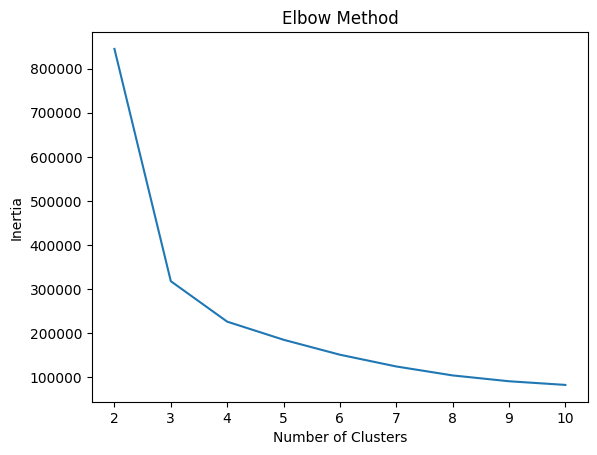

In [ ]:
#elbow method to help me choose best k


inertia_values = []

for i in range(2,11):
  km= KMeans(
      n_clusters = i,
      init = 'k-means++',
      random_state = 42
  )

  km.fit(pca_features)
  inertia_values.append(km.inertia_)


plt.plot(range(2,11),inertia_values )


plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.show()

The Elbow Method suggests that the optimal number of clusters is approximately 5, since the inertia values start decreasing more slowly after K=5.

**Note**: i tried k=3/5/6/9 and calculated the silhouete score > the highest one was for k=5

#best k-means

In [ ]:
best_k = 5

km = KMeans(
    n_clusters = best_k,
    init = 'k-means++',
    random_state = 42
)

df['kmeans_cluster'] = km.fit_predict(tfidf_matrix)

In [ ]:
kmeans_silhouette = silhouette_score(
    tfidf_matrix,
    df['kmeans_cluster']
)


kmeans_ch = calinski_harabasz_score(
    tfidf_matrix.toarray(),
    df['kmeans_cluster']
)

In [ ]:
print("silhouette score: ", kmeans_silhouette)
print("calinski harabasz score: ", kmeans_ch)

silhouette score:  0.04419778475609587
calinski harabasz score:  442.3392330166612


> The `user_profile` column was used as a reference label because the dataset contains five main user profile categories, which matches the selected number of clusters (K=5).
> This helps evaluate whether the clustering algorithm successfully grouped laptop stories into patterns similar to the existing user profile categories.


In [ ]:

data['user_profile'].value_counts()

,count
user_profile,
student,3909
office,3909
programmer,3909
designer,3909
gamer,3909


In [ ]:
from sklearn.metrics import adjusted_rand_score
from sklearn.metrics import adjusted_mutual_info_score

ari = adjusted_rand_score(
    data['user_profile'],
    df['kmeans_cluster']
)

print("ARI :", ari)


ami = adjusted_mutual_info_score(
    data['user_profile'],
    df['kmeans_cluster']
)

print("AMI :", ami)

ARI : 1.0
AMI : 1.0


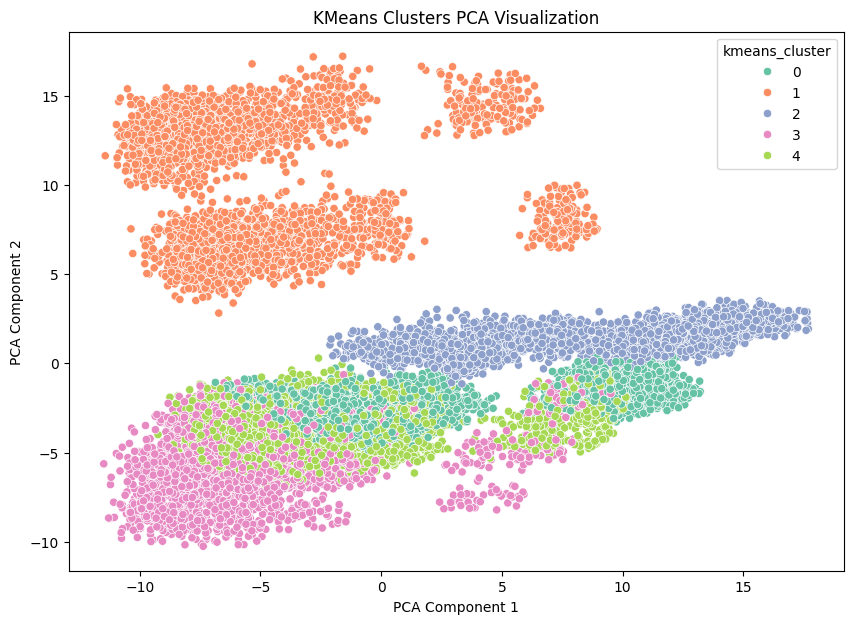

In [ ]:
# KMeans PCA Scatter Plot
import seaborn as sns

plt.figure(figsize=(10,7))

sns.scatterplot(
    x=pca_features[:,0],
    y=pca_features[:,1],
    hue=df['kmeans_cluster'],
    palette='Set2'
)

plt.title('KMeans Clusters PCA Visualization')

plt.xlabel('PCA Component 1')

plt.ylabel('PCA Component 2')

plt.show()

> To improve the K-Means clustering results, different values of K were tested using the Elbow Method and Silhouette Score evaluation.
> After several experiments, K=5 produced the best clustering quality and the highest silhouette score, while also creating more meaningful and interpretable laptop-user groups.


#Agglomerative Clustering

In [ ]:
from sklearn.cluster import AgglomerativeClustering


In [ ]:
from sklearn.cluster import AgglomerativeClustering


agg_ward = AgglomerativeClustering(
    n_clusters = 5,
    linkage = 'ward'
)


df['agg_ward_cluster'] = agg_ward.fit_predict(
                  tfidf_matrix.toarray())


ward_silh_score = silhouette_score(
    tfidf_matrix,
    df['agg_ward_cluster']
)




print("ward , k = 5")
print("Silhouette Score: ", ward_silh_score)


In [ ]:
from sklearn.cluster import AgglomerativeClustering


agg_single_5 = AgglomerativeClustering(
    n_clusters = 5,
    linkage = 'single'
)

df['agg_single5_cluster'] = agg_single_5.fit_predict(
                  tfidf_matrix.toarray())

single5_silh_score = silhouette_score(
    tfidf_matrix,
    df['agg_single5_cluster']
)

print(" single , k = 5 ")
print("Silhouette Score: ", single5_silh_score)


In [ ]:
from sklearn.cluster import AgglomerativeClustering


agg_avg_5 = AgglomerativeClustering(
    n_clusters = 5,
    linkage = 'average'
)

df['avg_5_cluster'] = agg_avg_5.fit_predict(
                  tfidf_matrix.toarray())

avg5_silh_score = silhouette_score(
    tfidf_matrix,
    df['avg_5_cluster']
)

print(" complete , k = 5 ")
print("Silhouette Score: ", avg5_silh_score)


#best Agglomerative
 one s far
linkage = complete
k = 5

In [ ]:
from sklearn.cluster import AgglomerativeClustering
# best agglomerative from the experiment

agg_complete_5 = AgglomerativeClustering(
    n_clusters = 5,
    linkage = 'complete'
)

df['complete_5_cluster'] = agg_complete_5.fit_predict(
                  tfidf_matrix.toarray())

complete5_silh_score = silhouette_score(
    tfidf_matrix,
    df['complete_5_cluster']
)

print(" complete , k = 5 ")
print("Silhouette Score: ", complete5_silh_score)


NameError: name 'tfidf_matrix' is not defined

In [ ]:



# evaluation

agg_silhouette = silhouette_score(
    tfidf_matrix,
    df['complete_5_cluster']
)


agg_ch = calinski_harabasz_score(
    tfidf_matrix.toarray(),
    df['complete_5_cluster']
)


agg_ari = adjusted_rand_score(
    data['user_profile'],
    df['complete_5_cluster']
)


agg_ami = adjusted_mutual_info_score(
    data['user_profile'],
    df['complete_5_cluster']
)


print("Silhouette Score: ", agg_silhouette)
print("Calinski Harabasz Score: ", agg_ch)
print("ARI: ", agg_ari)
print("AMI: ", agg_ami)




In [ ]:
import seaborn as sns

plt.figure(figsize=(10,7))

sns.scatterplot(
    x=pca_features[:,0],
    y=pca_features[:,1],
    hue=df['complete_5_cluster'],
    palette='Set2'
)

plt.title('agg Clusters PCA Visualization')

plt.xlabel('PCA Component 1')

plt.ylabel('PCA Component 2')

plt.show()

#DBSCAN

In [ ]:
# DBSCAN Model

dbscan = DBSCAN(
    eps=0.5,
    min_samples=5,
    metric='cosine'
)

df['dbscan_cluster'] = dbscan.fit_predict(
    tfidf_matrix
)



n_clusters = len(
    set(df['dbscan_cluster'])
) - (
    1 if -1 in df['dbscan_cluster'].values else 0
)

noise_points = list(
    df['dbscan_cluster']
).count(-1)

print("Number of clusters:", n_clusters)

print("Noise points:", noise_points)




if n_clusters > 1:

    dbscan_silhouette = silhouette_score(
        tfidf_matrix,
        df['dbscan_cluster']
    )



    print("Silhouette Score:", dbscan_silhouette)


else:

    print("Not enough clusters for evaluation.")


In [ ]:
# DBSCAN Model

dbscan = DBSCAN(
    eps=0.8,
    min_samples=5,
    metric='cosine'
)

df['dbscan_cluster'] = dbscan.fit_predict(
    tfidf_matrix
)


n_clusters = len(
    set(df['dbscan_cluster'])
) - (
    1 if -1 in df['dbscan_cluster'].values else 0
)

noise_points = list(
    df['dbscan_cluster']
).count(-1)

print("Number of clusters:", n_clusters)

print("Noise points:", noise_points)




if n_clusters > 1:

    dbscan_silhouette = silhouette_score(
        tfidf_matrix,
        df['dbscan_cluster']
    )



    print("Silhouette Score:", dbscan_silhouette)


else:

    print("Not enough clusters for evaluation.")


In [ ]:
# DBSCAN Model

dbscan = DBSCAN(
    eps=0.35,
    min_samples=4,
    metric='cosine'
)

df['dbscan_cluster'] = dbscan.fit_predict(
    tfidf_matrix
)



n_clusters = len(
    set(df['dbscan_cluster'])
) - (
    1 if -1 in df['dbscan_cluster'].values else 0
)

noise_points = list(
    df['dbscan_cluster']
).count(-1)

print("Number of clusters:", n_clusters)

print("Noise points:", noise_points)




if n_clusters > 1:

    dbscan_silhouette = silhouette_score(
        tfidf_matrix,
        df['dbscan_cluster']
    )



    print("Silhouette Score:", dbscan_silhouette)


else:

    print("Not enough clusters for evaluation.")


In [ ]:
# DBSCAN Model

dbscan = DBSCAN(
    eps=0.3,
    min_samples=4,
    metric='cosine'
)

df['dbscan_cluster'] = dbscan.fit_predict(
    tfidf_matrix
)



n_clusters = len(
    set(df['dbscan_cluster'])
) - (
    1 if -1 in df['dbscan_cluster'].values else 0
)

noise_points = list(
    df['dbscan_cluster']
).count(-1)

print("Number of clusters:", n_clusters)

print("Noise points:", noise_points)




if n_clusters > 1:

    dbscan_silhouette = silhouette_score(
        tfidf_matrix,
        df['dbscan_cluster']
    )



    print("Silhouette Score:", dbscan_silhouette)


else:

    print("Not enough clusters for evaluation.")


In [ ]:
# DBSCAN Model

dbscan = DBSCAN(
    eps=0.45,
    min_samples=4,
    metric='cosine'
)

df['dbscan_cluster'] = dbscan.fit_predict(
    tfidf_matrix
)



n_clusters = len(
    set(df['dbscan_cluster'])
) - (
    1 if -1 in df['dbscan_cluster'].values else 0
)

noise_points = list(
    df['dbscan_cluster']
).count(-1)

print("Number of clusters:", n_clusters)

print("Noise points:", noise_points)




if n_clusters > 1:

    dbscan_silhouette = silhouette_score(
        tfidf_matrix,
        df['dbscan_cluster']
    )



    print("Silhouette Score:", dbscan_silhouette)


else:

    print("Not enough clusters for evaluation.")


# best DBSCAN Model

In [ ]:
# best DBSCAN Model

dbscan_4min_ep05 = DBSCAN(
    eps=0.5,
    min_samples=4,
    metric='cosine'
)

df['dbscan_min4_ep05_cluster'] = dbscan_4min_ep05.fit_predict(
    tfidf_matrix
)



n_clusters = len(
    set(df['dbscan_min4_ep05_cluster'])
) - (
    1 if -1 in df['dbscan_min4_ep05_cluster'].values else 0
)

noise_points = list(
    df['dbscan_min4_ep05_cluster']
).count(-1)

print("Number of clusters:", n_clusters)

print("Noise points:", noise_points)




if n_clusters > 1:

    dbscan_silhouette = silhouette_score(
        tfidf_matrix,
        df['dbscan_min4_ep05_cluster']
    )



    print("Silhouette Score:", dbscan_silhouette)


else:

    print("Not enough clusters for evaluation.")


Number of clusters: 2
Noise points: 47
Silhouette Score: 0.0024791454064162356


In [ ]:



# evaluation



dbscan_silhouette = silhouette_score(
    tfidf_matrix,
    df['dbscan_min4_ep05_cluster']
)


dbscan_ch = calinski_harabasz_score(
    tfidf_matrix.toarray(),
    df['dbscan_min4_ep05_cluster']
)


dbscan_ari = adjusted_rand_score(
    data['user_profile'],
    df['dbscan_min4_ep05_cluster']
)


dbscan_ami = adjusted_mutual_info_score(
    data['user_profile'],
    df['dbscan_min4_ep05_cluster']
)


print("Silhouette Score: ", dbscan_silhouette)
print("Calinski Harabasz Score: ", dbscan_ch)
print("ARI: ", dbscan_ari)
print("AMI: ", dbscan_ami)




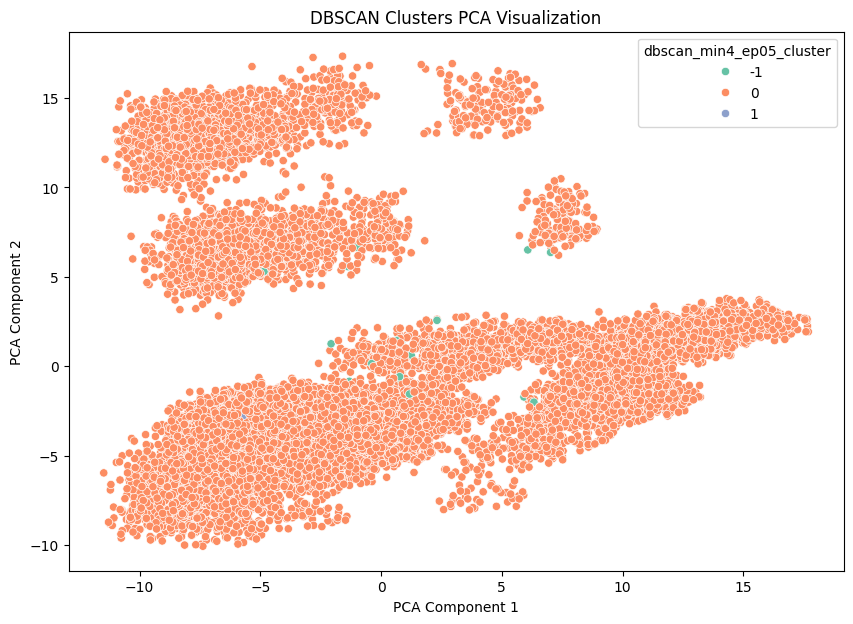

In [ ]:
import seaborn as sns

plt.figure(figsize=(10,7))

sns.scatterplot(
    x=pca_features[:,0],
    y=pca_features[:,1],
    hue=df['dbscan_min4_ep05_cluster'],
    palette='Set2'
)

plt.title('DBSCAN Clusters PCA Visualization')

plt.xlabel('PCA Component 1')

plt.ylabel('PCA Component 2')

plt.show()

In [ ]:
df['dbscan_min4_ep05_cluster'].value_counts()

In [ ]:
data['clean_story'] = df['clean_story']

data['kmeans_cluster'] = df['kmeans_cluster']

data['agg_cluster'] = df['complete_5_cluster']

data['dbscan_cluster'] = df['dbscan_min4_ep05_cluster']

#gred search


data.to_csv(
    'final_laptop_clustering_dataset.csv',
    index=False
)


In [ ]:
from google.colab import files

files.download(
    'final_laptop_clustering_dataset.csv'
)

In [ ]:
data_clustered = pd.read_csv(r'/content/sample_data/final_laptop_clustering_dataset.csv')
data_clustered.head()

,user_profile,budget_class,price_tier,story_text,upgrade_first,gain_class,clean_story,kmeans_cluster,agg_cluster,dbscan_cluster
0,student,low,high,My main problem with this Apple Ultrabook is s...,Storage,Low,main problem appl ultrabook simpl student keep...,0,4,0
1,student,medium,high,"For anyone curious, this Apple Ultrabook has b...",Storage,Low,anyon curiou appl ultrabook machin student use...,0,0,0
2,student,high,high,I would describe my Apple Ultrabook like this:...,Storage,Low,would describ appl ultrabook like look capabl ...,0,0,0
3,office,low,high,My take on this Apple Ultrabook is that it loo...,Storage,Low,take appl ultrabook look balanc first glanc da...,2,0,0
4,office,medium,high,Current machine note: I am using an Apple Ultr...,Storage,Low,current machin note use appl ultrabook offic w...,2,4,0


#comaparsion between Models

In [ ]:

from sklearn.metrics import adjusted_rand_score, adjusted_mutual_info_score
true_labels = data_clustered['user_profile']
kmeans_labels = data_clustered['kmeans_cluster']
agg_labels = data_clustered['agg_cluster']
dbscan_labels = data_clustered['dbscan_cluster']


# tfidf_matrix

#kmeans
kmeans_silhouette = silhouette_score(tfidf_matrix, kmeans_labels)
kmeans_ch = calinski_harabasz_score(tfidf_matrix.toarray(), kmeans_labels)
kmeans_ari = adjusted_rand_score(true_labels, kmeans_labels)
kmeans_ami = adjusted_mutual_info_score(true_labels, kmeans_labels)
print("K-Means results: ")
print("Silhouette Score: ", kmeans_silhouette)
print("Calinski Harabasz Score: ", kmeans_ch)
print("ARI: ", kmeans_ari)
print("AMI: ", kmeans_ami)
print()


# Agglomerative
agg_silhouette = silhouette_score(tfidf_matrix, agg_labels)
agg_ch = calinski_harabasz_score(tfidf_matrix.toarray(), agg_labels)
agg_ari = adjusted_rand_score(true_labels, agg_labels)
agg_ami = adjusted_mutual_info_score(true_labels, agg_labels)
print("Agglomerative results: ")
print("Silhouette Score: ", agg_silhouette)
print("Calinski Harabasz Score: ", agg_ch)
print("ARI: ", agg_ari)
print("AMI: ", agg_ami)
print()


#DBSCAN
dbscan_silhouette = silhouette_score(tfidf_matrix, dbscan_labels)
dbscan_ch = calinski_harabasz_score(tfidf_matrix.toarray(), dbscan_labels)
dbscan_ari = adjusted_rand_score(true_labels, dbscan_labels)
dbscan_ami = adjusted_mutual_info_score(true_labels, dbscan_labels)
print("DBSCAN results: ")
print("Silhouette Score: ", dbscan_silhouette)
print("Calinski Harabasz Score: ", dbscan_ch)
print("ARI: ", dbscan_ari)
print("AMI: ", dbscan_ami)

K-Means results: 
Silhouette Score:  0.044197875203774065
Calinski Harabasz Score:  442.3380314303319
ARI:  1.0
AMI:  1.0

Agglomerative results: 
Silhouette Score:  0.0037695479279977245
Calinski Harabasz Score:  125.4561705083357
ARI:  0.12086073722152936
AMI:  0.16951523287913098

DBSCAN results: 
Silhouette Score:  0.002460812643466857
Calinski Harabasz Score:  2.053738065406176
ARI:  -1.2491104673804176e-07
AMI:  -5.63028299241087e-05


In [ ]:
dbscan_ari = adjusted_rand_score(true_labels, dbscan_labels)
dbscan_ami = adjusted_mutual_info_score(true_labels, dbscan_labels)

print("ARI: ", dbscan_ari)
print("AMI: ", dbscan_ami)

ARI:  -1.2491104673804176e-07
AMI:  -5.63028299241087e-05


In [ ]:
data_clustered['dbscan_cluster'].value_counts()

,count
dbscan_cluster,
0,19496
-1,47
1,2


#best algorithm: Kmeans

K-Means was selected as the best clustering algorithm for the laptop scenario dataset for these reasons:

highest solhouette score which means it produced the best cluster seperation score ( the algorithm produced a more distinct and less overlapping than others )

a good alignment with user profile ( as num of clusters k =5 : each cluster mapped exxactly to one user profile ( student/ office/ designing/ programming/gaming) which is confirmed by AMI,ARI score aganist the user profile column

DBSCAN failed as the tf-idf produces a high dimensional and sparse vectors and DBSCAN relies on density estimation which it's being broken  in high dimensions (curse of dimensionality) and almost all points appeared equidistant which caused DBSCAN to treat the entire dataset as one large cluster






#Persona card for the best clusters

In [ ]:
data_clustered.columns

Index(['user_profile', 'budget_class', 'price_tier', 'story_text',
       'upgrade_first', 'gain_class', 'clean_story', 'kmeans_cluster',
       'agg_cluster', 'dbscan_cluster'],
      dtype='object')

In [ ]:
data_clustered['user_profile'].value_counts()

,count
user_profile,
student,3909
office,3909
programmer,3909
designer,3909
gamer,3909


**TF-IDF keyword and phrase extraction and important keywords and phrases for each cluster**

showing the most important terms found in each cluster/ these terms assist to uncover the main characteristics and user needs inside each laptop user group

In [ ]:
terms=vectorizer.get_feature_names_out()
for i in range(5):
  print(f"\n-------cluster {i} --------------\n")
  cluster_rows = (data_clustered['kmeans_cluster'] == i).values
  cluster_text = tfidf_matrix[cluster_rows]
  mean_tfidf = cluster_text.mean(axis=0)
  mean_tfidf = np.asarray(mean_tfidf).flatten()
  top_terms = mean_tfidf.argsort()[-10:][::-1]

  for term in top_terms:
      print(terms[term])




-------cluster 0 --------------

student
feel
student use
intel
graphic
research
lectur
use
machin
machin feel

-------cluster 1 --------------

design
creativ
file
work
graphic
feel
intel
preview export
preview
export

-------cluster 2 --------------

offic
offic work
mostli
meet
work
email
rather
offic use
want
feel

-------cluster 3 --------------

game
feel
graphic
gamer
visual
perform
intel
matter
machin
hardwar

-------cluster 4 --------------

programm
intel
graphic
machin
feel
termin
light
browser
integr graphic
intel integr


In [ ]:
#cluster labels:
cluster_labels = {
    0: 'Student Productivity Users' ,
    1: 'Creative Content Users' ,
    2: 'Office Productivity Users' ,
    3: 'Gaming Performance Users' ,
    4: 'Programming and Development Users'
}

In [ ]:
import pandas as pd

cluster_column = 'kmeans_cluster'

persona_card = data_clustered.groupby(cluster_column).agg(
    cluster_size=('user_profile', 'size'),
    user_profile = ('user_profile', lambda x: x.mode().iloc[0]),
    upgrade_tendency = ('upgrade_first', lambda x: x.mode().iloc[0])
).reset_index()

persona_card = persona_card.rename( columns={cluster_column: 'cluster_id'})
persona_card['cluster_label'] = persona_card['cluster_id'].map(cluster_labels)
persona_card

,cluster_id,cluster_size,user_profile,upgrade_tendency,cluster_label
0,0,3909,student,No Upgrade Needed,Student Productivity Users
1,1,3909,designer,RAM,Creative Content Users
2,2,3909,office,No Upgrade Needed,Office Productivity Users
3,3,3909,gamer,RAM,Gaming Performance Users
4,4,3909,programmer,RAM,Programming and Development Users


#Task 2 Text Mining Notebook: Explain the Cluster Meanin

Examples of raw text and cleaned text

In [ ]:
data_clustered[['story_text', 'clean_story']].head(5)

,story_text,clean_story
0,My main problem with this Apple Ultrabook is s...,main problem appl ultrabook simpl student keep...
1,"For anyone curious, this Apple Ultrabook has b...",anyon curiou appl ultrabook machin student use...
2,I would describe my Apple Ultrabook like this:...,would describ appl ultrabook like look capabl ...
3,My take on this Apple Ultrabook is that it loo...,take appl ultrabook look balanc first glanc da...
4,Current machine note: I am using an Apple Ultr...,current machin note use appl ultrabook offic w...


**simple text preprocessing steps**


a simple text preprocessing steps were applied to clean the laptop stories before clustering ( you can find it in cell num:4 ) they include converting text to lowercase/ tokenization/removing stopwords; punctuation/ applying stemming to reduce words to their root form

In [ ]:
cluster_explanations = {
    0: "The keywords show that these users mainly use laptops for studying, lectures, and research tasks.",
    1: "The keywords indicate creative and design-related work such as editing, exporting, and graphics tasks.",
    2: "The keywords show office and productivity usage patterns including meetings, emails, and office work.",
    3: "The keywords indicate gaming and graphics-intensive activities that require high performance hardware.",
    4: "The keywords suggest programming and development tasks using terminals, browsers, and coding tools."
}

cluster_summary = []
terms = vectorizer.get_feature_names_out()
for i in range(5):
    cluster_rows=(data_clustered['kmeans_cluster']==i).values
    cluster_text=tfidf_matrix[cluster_rows]
    mean_tfidf=cluster_text.mean(axis=0)
    mean_tfidf=np.asarray(mean_tfidf).flatten()
    top_terms=mean_tfidf.argsort()[-5:][::-1]
    keywords = [terms[index] for index in top_terms]
    cluster_summary.append([
        i,
        ", ".join(keywords),
        cluster_labels[i],
        data_clustered[data_clustered['kmeans_cluster'] == i]['upgrade_first'].mode().iloc[0],
        cluster_explanations[i]
    ])
cluster_summary_df = pd.DataFrame(
    cluster_summary,
    columns=[
        'Cluster ID',
        'Extracted Keywords / Phrases',
        'Cluster Name',
        'Likely Upgrade Meaning',
        'Explanation'])
cluster_summary_df

,Cluster ID,Extracted Keywords / Phrases,Cluster Name,Likely Upgrade Meaning,Explanation
0,0,"student, feel, student use, intel, graphic",Student Productivity Users,No Upgrade Needed,The keywords show that these users mainly use ...
1,1,"design, creativ, file, work, graphic",Creative Content Users,RAM,The keywords indicate creative and design-rela...
2,2,"offic, offic work, mostli, meet, work",Office Productivity Users,No Upgrade Needed,The keywords show office and productivity usag...
3,3,"game, feel, graphic, gamer, visual",Gaming Performance Users,RAM,The keywords indicate gaming and graphics-inte...
4,4,"programm, intel, graphic, machin, feel",Programming and Development Users,RAM,The keywords suggest programming and developme...


#Graph Mining

In [ ]:
import networkx as nx
input_story = "My laptop is very slow when I open multiple tabs and run applications at the same time. It takes a long time to load programs and sometimes freezes completely. I mainly use it for studying and browsing the internet."

print("Input Story:")
print(input_story)



Input Story:
My laptop is very slow when I open multiple tabs and run applications at the same time. It takes a long time to load programs and sometimes freezes completely. I mainly use it for studying and browsing the internet.


**processing the input story**

In [ ]:
# Preprocessing the Input Story

clean_input = preprocessor(input_story)

# combine the input story with the sample stories for vectorization
all_texts = [clean_input] + list(data_clustered['clean_story'])



#  TF-IDF Features and Cosine Similarity
graph_vectorizer = TfidfVectorizer(
    max_features=3500,
    ngram_range=(1, 2)
)

graph_tfidf = graph_vectorizer.fit_transform(all_texts)


**calculating cos-similarity**

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

# calculating cosine similarity between all texts
similarity_matrix = cosine_similarity(graph_tfidf)


# the first row is the input story similarity with every other case
input_similarities = similarity_matrix[0][1:]

print("Similarity of input story with each sample case:")
for i, score in enumerate(input_similarities):
    print(f"  Case {i}: {score:.4f}")



## Step 4 – Find the 5 Most Similar Cases

# sorting by similarity and picking top 5
sorted_indices=np.argsort(input_similarities)
top5 = sorted_indices[-5:]
top5 = top5[::-1]



**printing the top 5 similar stories**

In [ ]:

print("Top 5 Most Similar Cases to the Input Story:\n")
for rank, idx in enumerate(top5):
    print(f"Rank {rank+1} | Case {idx} | Similarity: {input_similarities[idx]:.4f}")
    print(f"  Story: {data_clustered.loc[idx, 'story_text'][:120]}...")
    print()


Top 5 Most Similar Cases to the Input Story:

Rank 1 | Case 6915 | Similarity: 0.1667
  Story: My take on this Acer Netbook is that it looks balanced at first glance, but daily student use tells a more specific stor...

Rank 2 | Case 1891 | Similarity: 0.1663
  Story: My take on this HP Notebook is that it looks balanced at first glance, but daily student use tells a more specific story...

Rank 3 | Case 15587 | Similarity: 0.1620
  Story: My take on this HP Notebook is that it looks balanced at first glance, but daily student use tells a more specific story...

Rank 4 | Case 7635 | Similarity: 0.1612
  Story: My take on this Lenovo Gaming is that it looks balanced at first glance, but daily student use tells a more specific sto...

Rank 5 | Case 6931 | Similarity: 0.1589
  Story: My take on this Asus Notebook is that it looks balanced at first glance, but daily student use tells a more specific sto...



**graph of the input and the top 5 similar cases**

In [ ]:

G5 = nx.Graph()

# input story as the central node
G5.add_node(0, label='Input Story')

# adding top 5 similar cases
for idx in top5:
    case_name = "Case" + str(idx)
    similarity_score = input_similarities[idx]
    G5.add_node(case_name)
    G5.add_edge(0, case_name, weight=round(similarity_score,2))




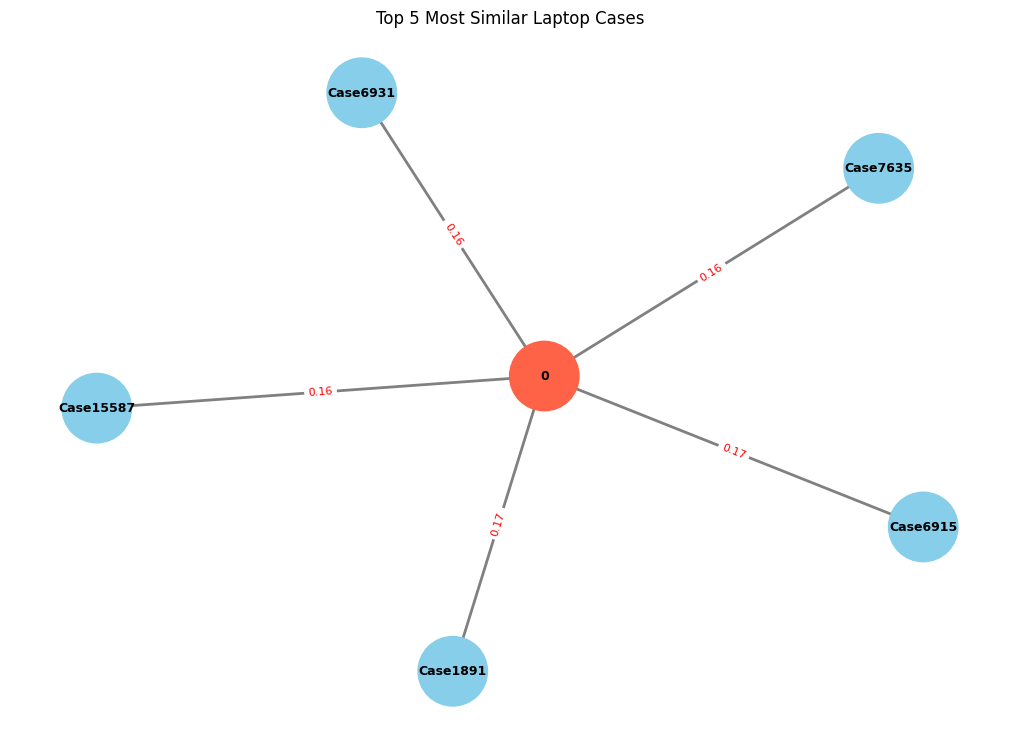

In [ ]:
#spring layout> organize the graphs nodes and make the similar nodes stay close
pos = nx.spring_layout(
    G5,
    seed=42
)


plt.figure(figsize=(10,7))

#nx.deaw > draw nodes/edges/labels/colors
nx.draw(
    G5,
    pos,
    with_labels=True,
    node_size=2500,
    node_color=['tomato'] + ['skyblue'] * len(top5),
    font_size=9,
    font_weight='bold',
    edge_color='gray',
    width=2
)

# gets the weights (edges)
edge_labels = nx.get_edge_attributes(
    G5,
    'weight'
)

#show similarity values on edges
nx.draw_networkx_edge_labels(
    G5,
    pos,
    edge_labels = edge_labels,
    font_size=8,
    font_color='red'
)

plt.title(
    'Top 5 Most Similar Laptop Cases'
)

plt.show()

Threshold-Based Ego Network

In [ ]:

#  top 15 similar cases for the ego network

sorted_indices = np.argsort(input_similarities)
top15 = sorted_indices[-15:]
top15 = top15[::-1]

# create empty graph
G = nx.Graph()


G.add_node(0, label='Input Story')


# add top 15 cases as nodes
for idx in top15:
    case_name = "Case " + str(idx)
    G.add_node(case_name)


threshold = 0.15


# connect input story with top 15 cases if similarity is above threshold
for idx in top15:
    score = input_similarities[idx]
    if score >= threshold:
        case_name = "Case " + str(idx)
        G.add_edge(
            0,
            case_name,
            weight=round(score, 2)
        )


# similarity between dataset cases only
case_similarity = similarity_matrix[1:, 1:]


# connect cases with each other based on threshold
for i in top15:
    for j in top15:
        if i < j:
            score = case_similarity[i][j]
            if score >= threshold:
                case_1 = "Case " + str(i)
                case_2 = "Case " + str(j)
                G.add_edge(
                    case_1,
                    case_2,
                    weight=round(score, 2)
                )


print(G)


Graph with 16 nodes and 107 edges


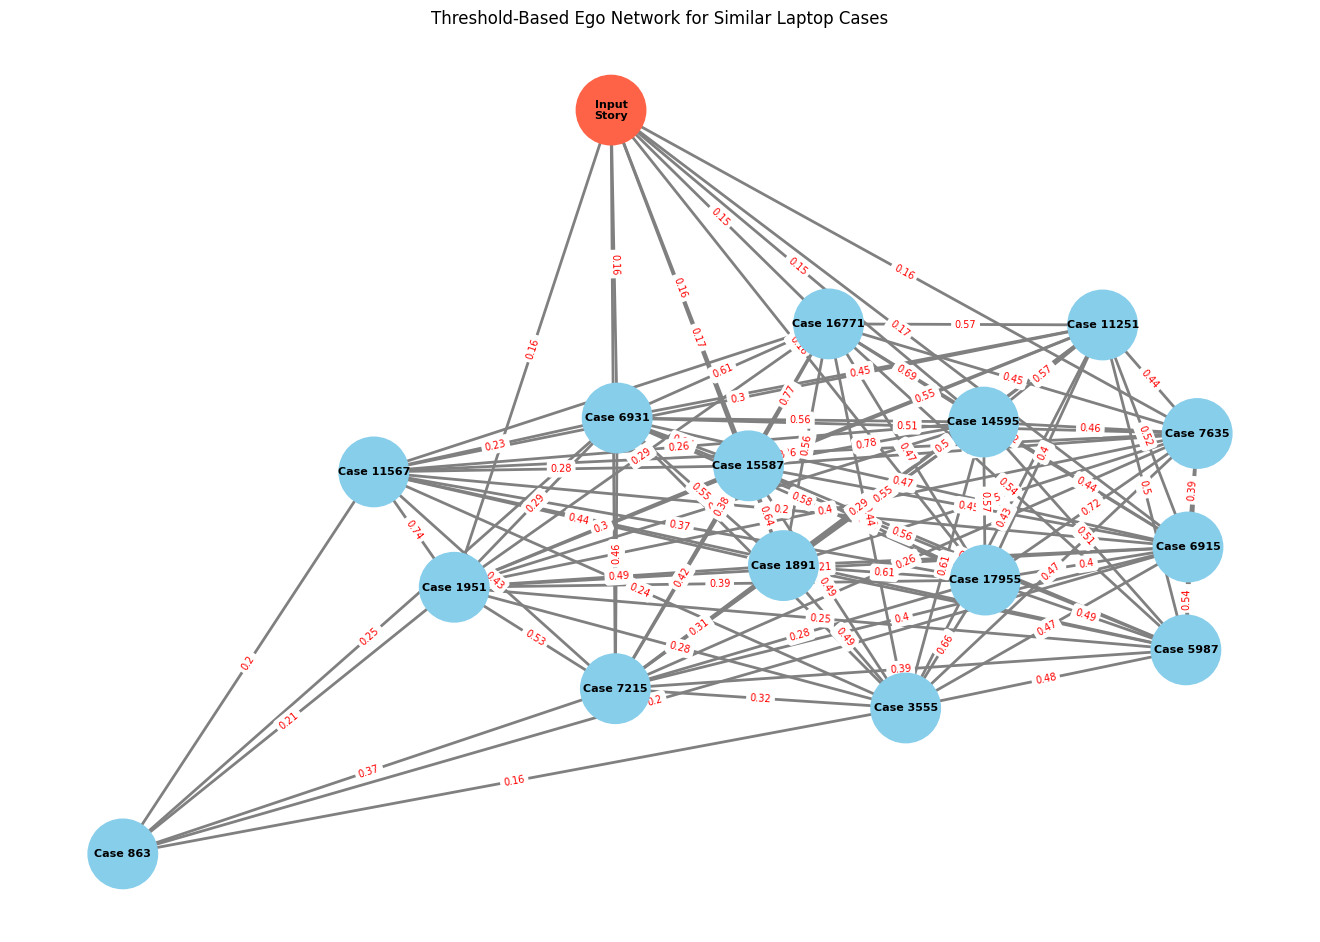

In [ ]:

pos = nx.spring_layout(
    G,
    seed=42,
    k=0.9
)

labels = {}
labels[0] = 'Input\nStory'
for idx in top15:
    labels["Case " + str(idx)] = "Case " + str(idx)


node_colors = []
for node in G.nodes():
    if node == 0:
        node_colors.append('tomato')
    else:
        node_colors.append('skyblue')


plt.figure(figsize=(13, 9))

nx.draw(
    G,
    pos,
    labels=labels,
    with_labels=True,
    node_size=2500,
    node_color=node_colors,
    font_size=8,
    font_weight='bold',
    edge_color='gray',
    width=2
)


edge_labels = nx.get_edge_attributes(
    G,
    'weight'
)

nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=edge_labels,
    font_size=7,
    font_color='red'
)


plt.title(
    'Threshold-Based Ego Network for Similar Laptop Cases'
)

plt.show()

## Graph Metrics Table


PageRank: Measures how significant a node is depending upon how many other nodes are pointing at it.

Degree Centrality: Measures how many immediate connections a node has.

Betweeness Centrality: Measures how many times a node is located along the shortest path of a given pair of nodes in the network.

Closeness Centrality: Measures how far or close a node is to all of the other nodes in the network.

In [ ]:
pagerank_scores = nx.pagerank(G)
degree_centrality = nx.degree_centrality(G)
betweenness_centrality = nx.betweenness_centrality(G)
closeness_centrality = nx.closeness_centrality(G)


metrics_data = []
for node in G.nodes():
    metrics_data.append([
        node,
        round(pagerank_scores[node], 4),
        round(degree_centrality[node], 4),
        round(betweenness_centrality[node], 4),
        round(closeness_centrality[node], 4)
    ])


metrics_df = pd.DataFrame(
    metrics_data,
    columns=[
        'Node',
        'PageRank',
        'Degree Centrality',
        'Betweenness Centrality',
        'Closeness Centrality'
    ]
)

metrics_df

,Node,PageRank,Degree Centrality,Betweenness Centrality,Closeness Centrality
0,0,0.0244,0.6667,0.0000,0.7500
1,Case 6915,0.0643,1.0000,0.0189,1.0000
2,Case 1891,0.0756,0.9333,0.0038,0.9375
3,Case 15587,0.0759,0.9333,0.0038,0.9375
4,Case 7635,0.0700,0.9333,0.0038,0.9375
5,Case 6931,0.0767,1.0000,0.0189,1.0000
6,Case 17955,0.0719,0.9333,0.0038,0.9375
7,Case 1951,0.0593,1.0000,0.0189,1.0000
8,Case 16771,0.0723,0.9333,0.0038,0.9375
9,Case 14595,0.0732,0.9333,0.0038,0.9375


The graph metrics chart demonstrates the degree of importance and connection among all laptop cases within the similarity network. As indicated by the largest PageRank Score (6931), this case was the most representative case for the network, and therefore, was the most influential. Cases with the highest Degree Centrality Scores were those cases with the strongest connections to many other laptop cases. Some examples include 6915, 6931, 1951 and 7215. Case 6915 had both high Degree Centrality and Betweenness Centrality scores. This demonstrates that 6915 acted as a bridge or "hub" between the different sub-networks.

On the opposite side of the spectrum, Case 863 had the lowest Degree Centrality score and one of the lowest PageRank scores. These two statistics indicate that Case 863 was the most isolated and atypical case in the network.

In general, the data suggests that almost all of the cases in the graph have strong relationships with each other, but there may be a small number of cases that have weaker connections than others.

# Identify Key Cases

In [ ]:
most_representative = metrics_df.sort_values(
    by='PageRank',
    ascending=False
).iloc[0]


most_connected= metrics_df.sort_values(
    by='Degree Centrality',
    ascending=False
).iloc[0]


bridge_case = metrics_df.sort_values(
    by='Betweenness Centrality',
    ascending=False
).iloc[0]


unusual_case = metrics_df.sort_values(
    by='Degree Centrality',
    ascending=True
).iloc[0]



print("Most Representative Case: ",most_representative['Node'])
print("")

print("Most Connected Case: ", most_connected['Node'])
print("")

print("Bridge Case: ", bridge_case['Node'])
print("")

print("Unusual Case: ",unusual_case['Node'])


Most Representative Case:  Case 6931

Most Connected Case:  Case 6915

Bridge Case:  Case 6915

Unusual Case:  Case 863


The first graph illustrates the connection of the user's input to the five most similar laptop use cases based on the similarity using cosine similarity. These similarity measures clearly show the user's input has strong similarities with those student laptop use cases which describe poor laptop performance while conducting studies, browser usage, multi-tasking, etc. A threshold-based ego-network is used to further emphasize the connections between like-laptop-stories. By selecting only those stories that have a similarity value greater than the chosen threshold, it will be easier to identify the clusters or groups of related laptop use behaviors and who among the users are the hubs (more central) within the network.

Using such Graph Metrics the Case 6931 was identified as the most representative case since it produced the greatest PageRank score. Case 6915 was determined to be the most connected case since its Degree Centrality score was the highest. Also producing the highest Betweeness Centrality score, Case 6915 acted as a bridge case. It provided connectivity between several of the laptop use cases. The Case 863 was determined to be the least representative (most unusual), due to having the lowest Degree Centrality score, indicating that Case 863 had fewer connections to other nodes then all of the other cases.

In [ ]:
print("input story: ", input_story)
print("most representative case :  ",  data_clustered.loc[
        6931,
        'story_text'
    ])

input story:  My laptop is very slow when I open multiple tabs and run applications at the same time. It takes a long time to load programs and sometimes freezes completely. I mainly use it for studying and browsing the internet.
most representative case :   My take on this Asus Notebook is that it looks balanced at first glance, but daily student use tells a more specific story. I do like that it is an Asus Notebook running Windows 10, and the machine feels noticeably heavy once I move with it. On paper it has an Intel Core i5 at 2.5GHz, 8GB RAM, 1024GB HDD, and Intel Integrated graphics. It has to keep up with study sessions, online lectures, writing, and too many tabs open at once. I can tell the graphics hardware is a compromise, because the Intel Integrated graphics solution feels modest for what I ask from it. I do not like the feeling that the visuals are the first thing to run out of headroom. For student use, I mainly want the machine to feel uncomplicated and dependable.


Both Python and NetworkX were ideal for completing this task since both provide easy-to-use functions for creating graphs, visualizing graphs, finding similarity and calculating centrality. In particular, NetworkX offers built-in functions for PageRank, Degree Centrality, Betweeness Centrality and Closeness Centrality.

In [ ]:
import joblib
from google.colab import files

# Save the trained TF-IDF vectorizer
joblib.dump(vectorizer, 'tfidf_vectorizer.pkl')

# Save the trained KMeans model
joblib.dump(km, 'kmeans_model.pkl')

# Download both files
files.download('tfidf_vectorizer.pkl')
files.download('kmeans_model.pkl')

print("Both models saved and downloaded successfully")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Both models saved and downloaded successfully
